In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/content/netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8807, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [17]:
df['country'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['director'].fillna('Unknown', inplace=True)

In [21]:
df.dropna(inplace=True)

In [25]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [29]:
# CHECK CONTENT TYPES
df['type'].value_counts()

,count
type,
Movie,6126
TV Show,2664


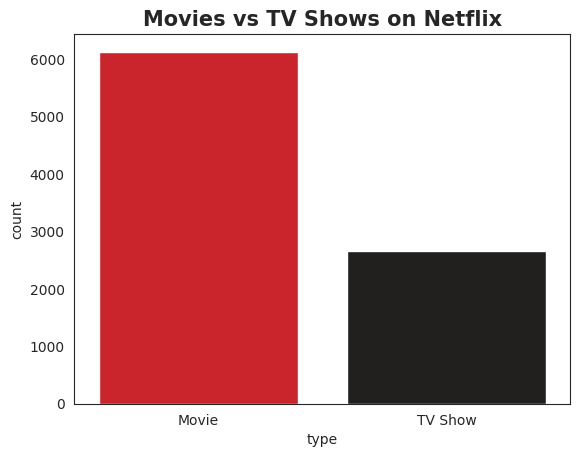

In [32]:
# VISUALIZATION 1 — MOVIES VS TV SHOWS
import seaborn as sns
import matplotlib.pyplot as plt
netflix_colors = ['#E50914', '#221F1F']

sns.set_style("white")
sns.countplot(x='type', data=df, palette=netflix_colors)

plt.title('Movies vs TV Shows on Netflix', fontsize=15, fontweight='bold')
plt.show()


In [36]:
# MOST CONTENT PRODUCING COUNTRIES
top_country = df['country'].value_counts().head(10)
top_country


,count
country,
United States,2809
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


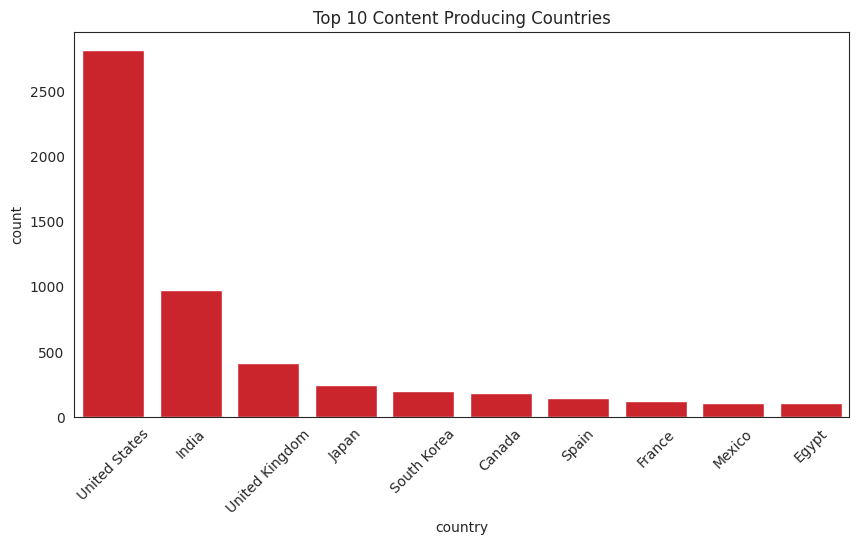

In [40]:
# VISUALIZATION 2 — TOP COUNTRIES
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
top_countries = df['country'].value_counts().drop('Unknown').head(10).index
sns.countplot(x='country', data=df, order=top_countries, color='#E50914')
plt.xticks(rotation=45)
plt.title('Top 10 Content Producing Countries')
plt.show()


In [42]:
# CONTENT ADDED OVER YEARS
# Convert date column:
df['date_added'] = pd.to_datetime(df['date_added'])
# Convert year column:
df['year_added'] = df['date_added'].dt.year
# Now count yearly additions:
yearly_content = df['year_added'].value_counts().sort_index()

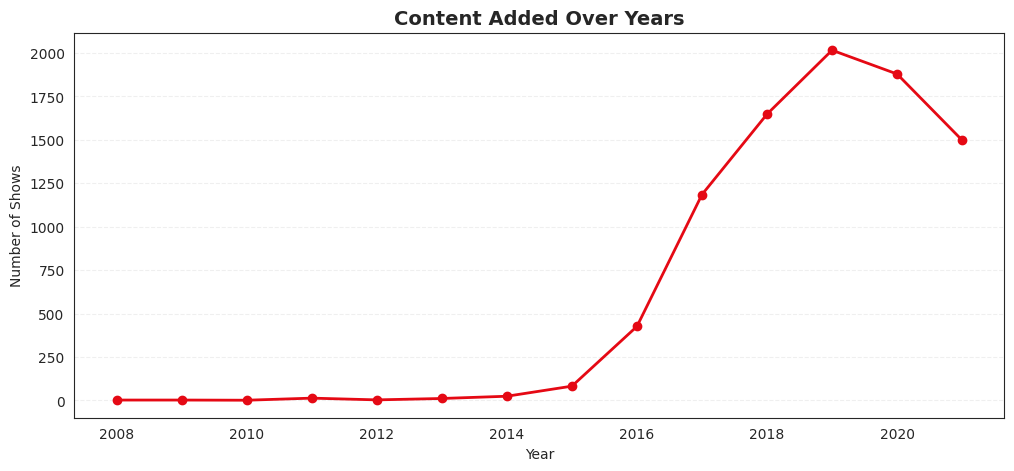

In [47]:
# VISUALIZATION 3 — CONTENT GROWTH
plt.figure(figsize=(12,5))

yearly_content.plot(kind='line', color='#E50914', marker='o', linewidth=2)

plt.title('Content Added Over Years', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Shows')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


In [49]:
# MOST COMMON RATINGS
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


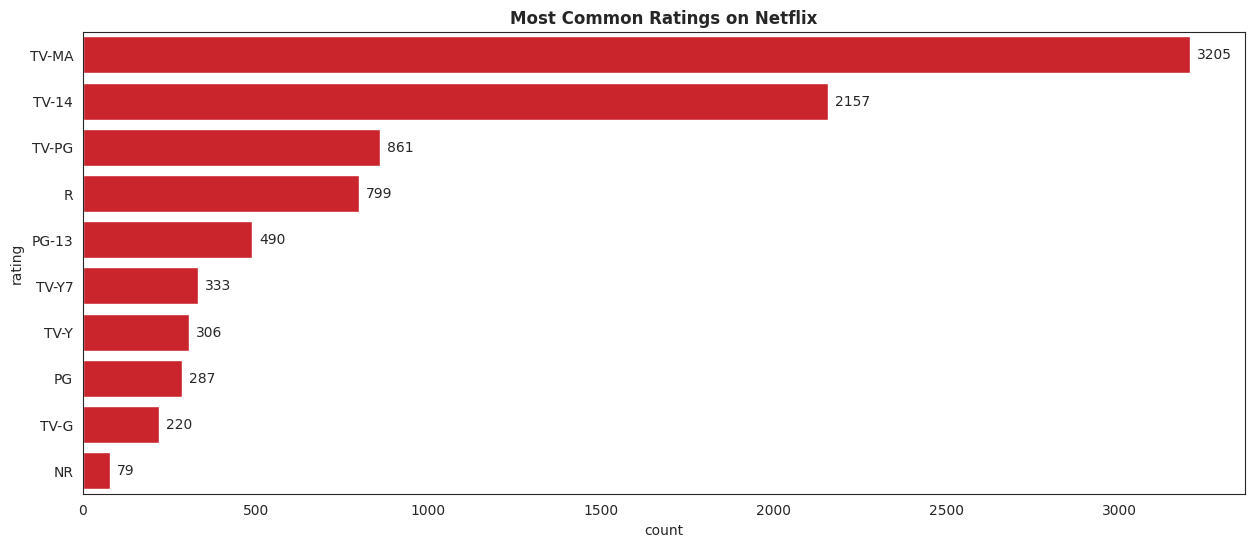

In [55]:
# RATINGS
plt.figure(figsize=(15,6))
ax = sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index[:10], color='#E50914')

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.title('Most Common Ratings on Netflix', fontweight='bold')
plt.show()


In [57]:
# MOST POPULAR GENRES
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,219
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


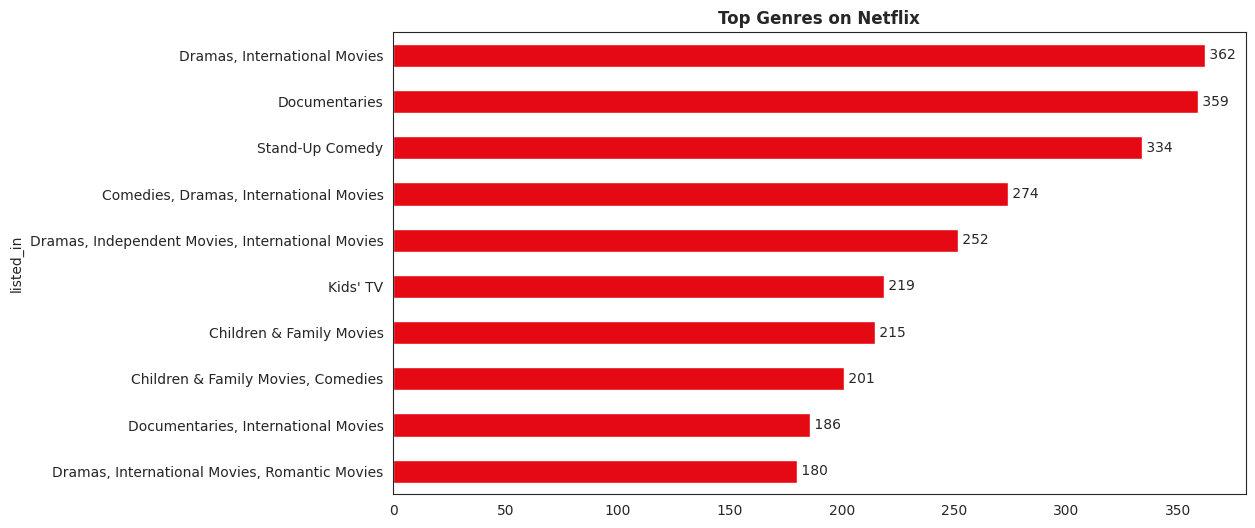

In [65]:
# VISUALIZATION 5 — TOP GENRES
plt.figure(figsize=(11,6))
ax = top_genres.sort_values().plot(kind='barh', color='#E50914')

for i, v in enumerate(top_genres.sort_values()):
    ax.text(v, i, f' {v}', va='center')

plt.title('Top Genres on Netflix', fontweight='bold')
plt.show()



In [67]:
# ANALYZE MOVIE DURATIONS
# First filter movies only:
movies = df[df['type'] == 'Movie']
# Extract numeric duration:
movies['duration'] = movies['duration'].str.replace(' min','')

movies['duration'] = movies['duration'].astype(float)

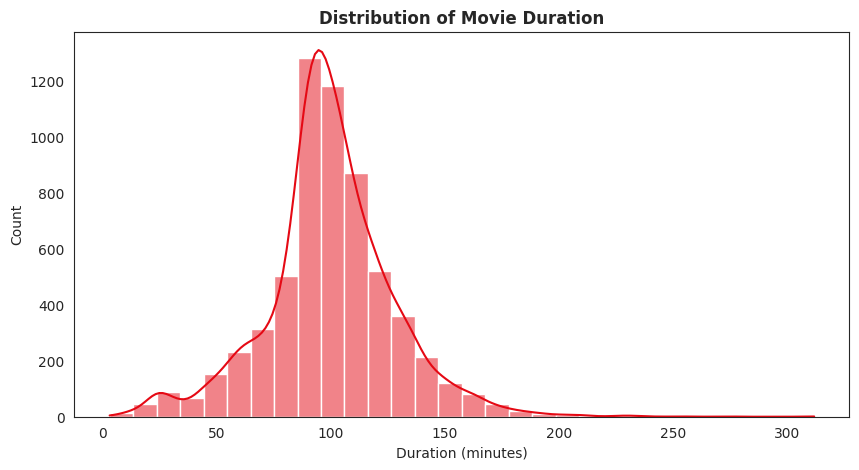

In [69]:
# VISUALIZATION 6 — MOVIE DURATION DISTRIBUTION
plt.figure(figsize=(10,5))
sns.histplot(movies['duration'], bins=30, color='#E50914', kde=True)
plt.title('Distribution of Movie Duration', fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()


In [73]:
# FIND TOP DIRECTORS
top_directors = df['director'].value_counts().head(10)
top_directors

,count
director,
Unknown,2621
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Youssef Chahine,12


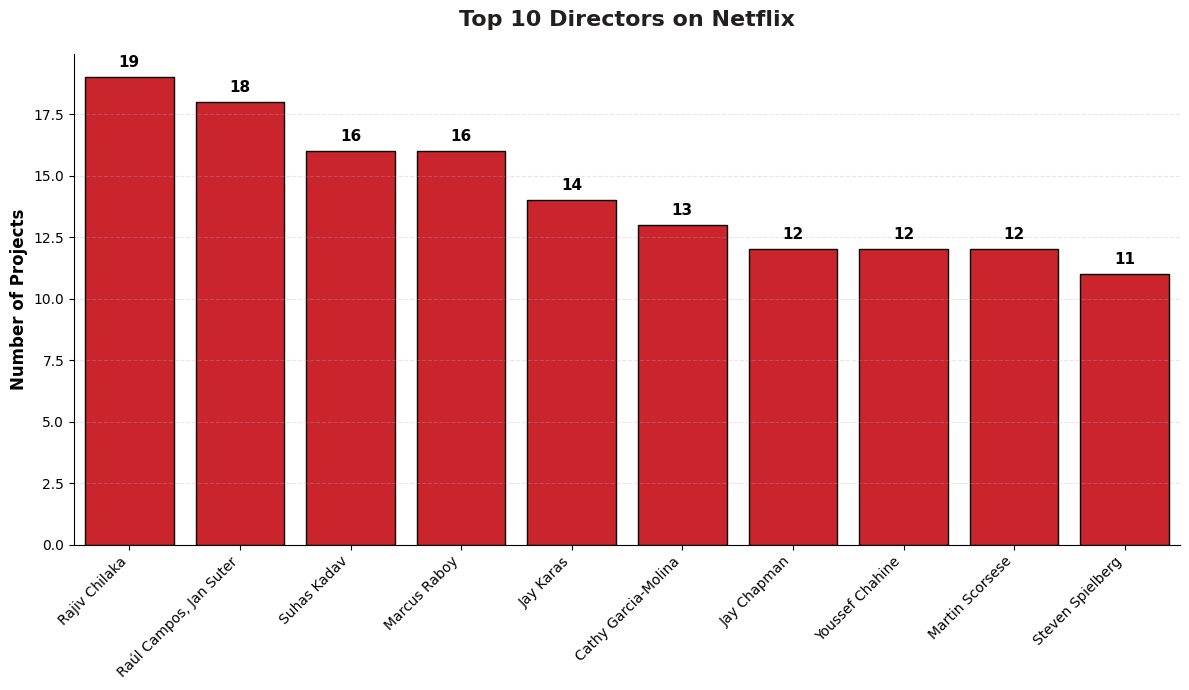

In [78]:
# VISUALIZATION 7 — TOP DIRECTORS
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
plt.figure(figsize=(12, 7))

top_directors_cleaned = df['director'].value_counts().drop('Unknown').head(10)

ax = sns.barplot(x=top_directors_cleaned.index, y=top_directors_cleaned.values,
                 color='#E50914', edgecolor='black', linewidth=1)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.title('Top 10 Directors on Netflix', fontsize=16, fontweight='bold', color='#221F1F', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Number of Projects', fontsize=12, fontweight='bold')
plt.xlabel('')

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()




# Introduction

Netflix is one of the world’s leading streaming platforms offering movies and TV shows across multiple countries and genres. With the rapid growth of digital entertainment, analyzing Netflix content can provide valuable insights into viewer trends, content distribution, ratings, and genre popularity.

# This project focuses on performing Exploratory Data Analysis (EDA) on the Netflix dataset using Python libraries such as Pandas, Matplotlib, and Seaborn.

# Objective

The main objective of this project is to analyze Netflix movies and TV shows data to identify trends and patterns.

Key objectives include:
- Understanding the distribution of Movies and TV Shows
- Identifying top content-producing countries
- Analyzing content growth over the years
- Finding the most common genres and ratings
- Exploring movie duration patterns
- Generating business insights using data visualization

# Dataset Information

The dataset used in this project contains information about Netflix Movies and TV Shows.

Dataset Features:
- Show ID
- Type (Movie/TV Show)
- Title
- Director
- Cast
- Country
- Date Added
- Release Year
- Rating
- Duration
- Genre (Listed In)
- Description

The dataset was obtained from Kaggle and contains real-world Netflix content information.

# Data Cleaning

Data cleaning is an important step before analysis. The following cleaning operations were performed:

- Removed duplicate records
- Handled missing values in columns such as country, director, and cast
- Converted date_added column into datetime format
- Cleaned duration column for numerical analysis
- Checked data types and corrected inconsistencies

These steps helped improve the quality and reliability of the dataset.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the dataset and identify patterns.

The analysis focused on:
- Distribution of Movies vs TV Shows
- Country-wise content distribution
- Year-wise content growth
- Most common ratings
- Popular genres
- Movie duration trends
- Top directors on Netflix

EDA helped uncover important insights and trends from the dataset.

# Visualizations

Various visualizations were created using Matplotlib and Seaborn libraries to better understand the data.

The visualizations include:
- Count plots
- Bar charts
- Line charts
- Histograms
- Heatmaps

These charts helped represent trends, comparisons, and distributions effectively.

# Insights

Key insights generated from the analysis are:

- Netflix contains more Movies than TV Shows
- The United States contributes the highest amount of content
- Netflix content increased rapidly after 2015
- TV-MA is the most common content rating
- Drama and International Movies are among the most popular genres
- Most movies have a duration between 80–120 minutes

These insights help understand Netflix’s content strategy and audience preferences.

# Conclusion

This project successfully analyzed Netflix Movies and TV Shows data using Python and data visualization techniques.

The analysis provided meaningful insights into content distribution, genre popularity, ratings, and growth trends. The project also improved skills in data cleaning, exploratory data analysis, and visualization using Pandas, Matplotlib, and Seaborn.

This project demonstrates how data analysis can be used to extract valuable business insights from real-world datasets.